In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import json
import ast
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
combined_data = pd.read_csv("data/combined_data.csv", index_col=False)

## Preprocessing

In [3]:
print(f"Combined Data Shape: {combined_data.shape}")
combined_data.head(10)

Combined Data Shape: (58780, 43)


,metadata_es_SortDate,metadata_endDate,metadata_language,metadata_title,metadata_objective,metadata_callIdentifier,metadata_freeKeywords,metadata_DATASOURCE,metadata_REFERENCE,metadata_topicAbbreviation,...,databaseLabel,database,summary,weight,content,accessRestriction,enrichedMetadata,children,highlightedFragments,citation
0,2025-10-31T03:41:37.475+0100,2024-08-31T00:00:00.000+0100,en,Sustainable 5G deployment model for future mob...,5GMed brings together key stakeholders of the ...,H2020-ICT-2018-20,"['5G-enabled mobility', 'cross-border corridor...",SEDIA_NONH2020_PROD,31045243951947,ICT-53-2020,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Sustainable 5G deployment model for future mob...,0.0,Sustainable 5G deployment model for future mob...,False,NaN,NaN,NaN,Sustainable 5G deployment model for future mob...
1,2025-10-30T22:04:29.119+0100,2026-12-31T00:00:00.000+0100,en,A microbial perspective of major historical ev...,Microbes have played fundamental roles through...,ERC-2020-STG,"['The Americas', 'Ancient DNA', 'Native Americ...",SEDIA_NONH2020_PROD,31045243948800,ERC-2020-STG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,A microbial perspective of major historical ev...,0.0,A microbial perspective of major historical ev...,False,NaN,NaN,NaN,A microbial perspective of major historical ev...
2,2025-10-30T02:03:33.117+0100,2025-02-28T00:00:00.000+0100,en,Embedded Electronic solutions for Polymer Inno...,El-Peacetolero’s overarching ambition is to de...,NFRP-2019-2020,"['Embedded optoelectronic system', 'Diagnosis ...",SEDIA_NONH2020_PROD,31045243945320,NFRP-2019-2020-04,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Embedded Electronic solutions for Polymer Inno...,0.0,Embedded Electronic solutions for Polymer Inno...,False,NaN,NaN,NaN,Embedded Electronic solutions for Polymer Inno...
3,2025-10-29T21:56:18.755+0100,2025-12-31T00:00:00.000+0100,en,"Accurate, Reliable and Optimized functional MA...",The AROMA project will provide the means enabl...,H2020-FETOPEN-2018-2020,"['Ultra-high field', 'methods', 'RF pulse desi...",SEDIA_NONH2020_PROD,31045243885876,FETOPEN-01-2018-2019-2020,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,"Accurate, Reliable and Optimized functional MA...",0.0,"Accurate, Reliable and Optimized functional MA...",False,NaN,NaN,NaN,"Accurate, Reliable and Optimized functional MA..."
4,2025-10-29T02:27:11.382+0100,2027-06-30T00:00:00.000+0100,en,Tracing language and population mixing in the ...,Chinese history was co-constructed by Han (Chi...,ERC-2019-ADG,"['populations', 'anthropolgoy', 'language cont...",SEDIA_NONH2020_PROD,31045243883700,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Tracing language and population mixing in the ...,0.0,Tracing language and population mixing in the ...,False,NaN,NaN,NaN,Tracing language and population mixing in the ...
5,2025-10-29T02:27:10.392+0100,2026-06-30T00:00:00.000+0100,en,Early Arabic Printing for the Arab Christians....,The main objective of the Project is to examin...,ERC-2019-ADG,"['Printing', 'Arab Christians', 'Arabic langua...",SEDIA_NONH2020_PROD,31045243883219,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Early Arabic Printing for the Arab Christians....,0.0,Early Arabic Printing for the Arab Christians....,False,NaN,NaN,NaN,Early Arabic Printing for the Arab Christians....
6,2025-10-29T02:27:06.718+0100,2024-06-30T00:00:00.000+0100,en,Integrated Urban Electric Mobility Solutions i...,The project SOLUTIONSplus aims to set up a glo...,H2020-LC-GV-2018-2019-2020,"['Innovation', 'demonstration', 'e-mobility', ...",SEDIA_NONH2020_PROD,31045243875041,LC-GV-05-2019,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Integrated Urban Electric Mobility Solutions i...,0.0,Integrated Urban Electric Mobility Solutions i...,False,NaN,NaN,NaN,Integrated Urban Electric Mobility Solutions i...
7,2025-10-28T23:11:01.954+0100,2025-06-30T00:00:00.000+0100,en,Dynamic longitudinal exposome trajectories in ...,"Environmental factors, including air and noise...",H2020-

In [4]:
combined_data.columns

Index(['metadata_es_SortDate', 'metadata_endDate', 'metadata_language',
       'metadata_title', 'metadata_objective', 'metadata_callIdentifier',
       'metadata_freeKeywords', 'metadata_DATASOURCE', 'metadata_REFERENCE',
       'metadata_topicAbbreviation', 'metadata_overallBudget',
       'metadata_participants', 'metadata_es_ContentType', 'metadata_acronym',
       'metadata_programmes', 'metadata_legalEntityNames',
       'metadata_countries', 'metadata_euContributionRate', 'metadata_url',
       'metadata_esST_URL', 'metadata_euContributionAmount',
       'metadata_ecSignatureDate', 'metadata_nutsCode',
       'metadata_programAbbreviation', 'metadata_projectId',
       'metadata_programId', 'metadata_startDate', 'metadata_status',
       'apiVersion', 'reference', 'url', 'contentType', 'language',
       'databaseLabel', 'database', 'summary', 'weight', 'content',
       'accessRestriction', 'enrichedMetadata', 'children',
       'highlightedFragments', 'citation'],
      dtype=

In [5]:
column_summary = pd.DataFrame({
    "Column": combined_data.columns,
    "Unique values": combined_data.nunique().values,
    "Missing values": combined_data.isna().sum().values,
    "Missing (%)": (combined_data.isna().mean() * 100).round(2).values,
    "Data type": combined_data.dtypes.astype(str).values,
}).sort_values("Missing values", ascending=False).reset_index(drop=True)

display(
    column_summary.style
    .hide(axis="index")
    .format({
        "Unique values": "{:,}",
        "Missing values": "{:,}",
        "Missing (%)": "{:.2f}%",
    })
    .background_gradient(subset=["Missing (%)"], cmap="Reds")
    .set_caption("Combined dataset: column overview")
    .set_properties(**{"text-align": "left"})
)

Column,Unique values,Missing values,Missing (%),Data type
highlightedFragments,0,"58,780",100.00%,float64
children,0,"58,780",100.00%,float64
enrichedMetadata,0,"58,780",100.00%,float64
metadata_euContributionRate,"3,197","13,074",22.24%,float64
metadata_nutsCode,"21,831","6,609",11.24%,str
metadata_freeKeywords,"54,463","3,978",6.77%,str
metadata_euContributionAmount,"30,251",52,0.09%,float64
metadata_overallBudget,"30,973",52,0.09%,float64
metadata_objective,"58,649",15,0.03%,str
content,"58,382",7,0.01%,str


In [6]:
stop_words = set(stopwords.words("english"))

# adding additional words
stop_words.update(["also", "project", "goal", "research", "new", "model", "data", "results", "approach", "method", "study", "analysis", "development", "based", "using", "use", "provide", "propose", "proposed", "solution", "solutions"])


In [7]:

def flatten(val):
    if isinstance(val, list):
        return " ".join(str(v) for v in val)
    return str(val) if pd.notna(val) else ""


In [8]:
# Specify relevant columns
RELEVANT_COLUMNS = ["metadata_objective", "metadata_title", "metadata_freeKeywords"]

# Combine the text columns into a single string per row. Remove list objects and turn them into strings, and replace new lines with spaces.
combined_data["_combined_text"] = combined_data[RELEVANT_COLUMNS].map(flatten).agg(" ".join, axis=1).str.replace('\n', ' ')

# Removing extra whitespace and punctuation, and converting to lowercase
combined_data["_combined_text"] = combined_data["_combined_text"].str.lower()  # Convert to lowercase
combined_data["_combined_text"] = combined_data["_combined_text"].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))  # Remove punctuation and special characters
combined_data["_combined_text"] = combined_data["_combined_text"].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))  # Remove stopwords
combined_data["_combined_text"] = combined_data["_combined_text"].str.replace(r'\s+', ' ', regex=True).str.strip()  # Remove extra whitespace

corpus = pd.DataFrame()
corpus["_combined_text"] = combined_data["_combined_text"]
corpus["startdate"] = combined_data["metadata_startDate"]


In [9]:
corpus[:5]  # Display the first 5 combined text entries

,_combined_text,startdate
0,5gmed brings together key stakeholders barcelo...,2020-09-01T00:00:00.000+0100
1,microbes played fundamental roles throughout e...,2020-11-01T00:00:00.000+0100
2,elpeacetoleros overarching ambition design trl...,2020-09-01T00:00:00.000+0100
3,aroma means enabling vivo noninvasive explorat...,2021-01-01T00:00:00.000+0100
4,chinese history coconstructed han chinese peop...,2021-01-01T00:00:00.000+0100


In [10]:
corpus.to_json(
    "data/corpus.json",
    orient="records",
    force_ascii=False,
    date_format="iso",
    indent=2,
)

In [11]:
combined_data["metadata_freeKeywords"].head(10)

0    ['5G-enabled mobility', 'cross-border corridor...
1    ['The Americas', 'Ancient DNA', 'Native Americ...
2    ['Embedded optoelectronic system', 'Diagnosis ...
3    ['Ultra-high field', 'methods', 'RF pulse desi...
4    ['populations', 'anthropolgoy', 'language cont...
5    ['Printing', 'Arab Christians', 'Arabic langua...
6    ['Innovation', 'demonstration', 'e-mobility', ...
7    ['Life-course', 'Cardiometabolic health trajec...
8    ['Integrated', 'advanced pan-arctic infrastruc...
9    ['Lasers', 'Physical Sciences', 'Optical Techn...
Name: metadata_freeKeywords, dtype: str

## Wordcloud

In [12]:
# Count complete keyword phrases instead of counting every word separately
keyword_frequencies = Counter()

for value in combined_data["metadata_freeKeywords"].dropna():
    if isinstance(value, list):
        keywords = value
    else:
        try:
            parsed_value = ast.literal_eval(str(value))
            keywords = parsed_value if isinstance(parsed_value, list) else [parsed_value]
        except (ValueError, SyntaxError):
            keywords = [value]

    for keyword in keywords:
        words = re.findall(r"[a-z]+", str(keyword).lower())
        phrase = " ".join(word for word in words if word not in stop_words)
        if phrase:
            keyword_frequencies[phrase] += 1

<unknown>:1: SyntaxWarning: invalid decimal literal


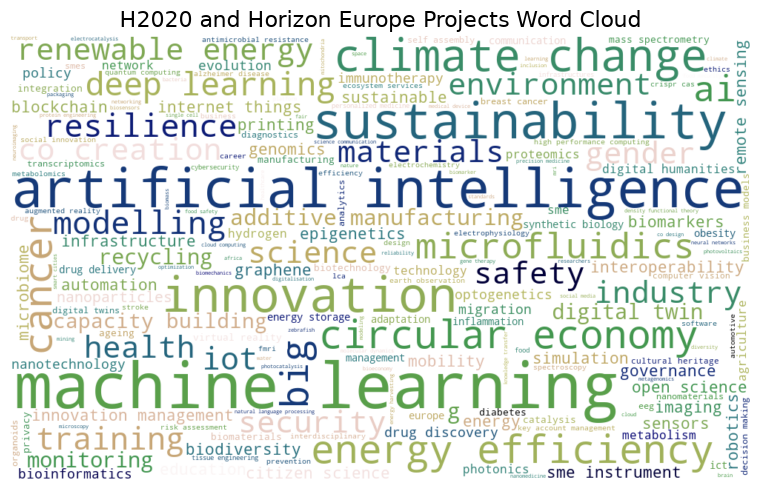

In [13]:
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="gist_earth_r",
    stopwords=stop_words,
    collocations=False,
).generate_from_frequencies(keyword_frequencies)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("H2020 and Horizon Europe Projects Word Cloud", fontsize=16)
plt.tight_layout()
plt.savefig("data/eda_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

## Date Distribution

Taking a closer look at the startdate, enddate and duration of the projects.

In [14]:
combined_data["start_year"] = pd.to_datetime(combined_data["metadata_startDate"], errors="coerce", utc=True).dt.year
combined_data["end_year"]   = pd.to_datetime(combined_data["metadata_endDate"],   errors="coerce", utc=True).dt.year

start_counts = combined_data["start_year"].value_counts().sort_index()
fig_start = px.bar(
    x=start_counts.index.astype(int).astype(str), y=start_counts.values,
    text=start_counts.values, labels={"x": "Year", "y": "Count"},
    title="Projects by Year | Start Date",
)
fig_start.update_traces(textposition="auto")
fig_start.write_image("data/eda_startdate_hist.png", width=1300, height=450, scale=2)
fig_start.show()

end_counts = combined_data["end_year"].value_counts().sort_index()
fig_end = px.bar(
    x=end_counts.index.astype(int).astype(str), y=end_counts.values,
    text=end_counts.values, labels={"x": "Year", "y": "Count"},
    title="Projects by Year | End Date",
)
fig_end.update_traces(textposition="auto")
fig_end.write_image("data/eda_enddate_hist.png", width=1300, height=450, scale=2)
fig_end.show()


In [15]:
combined_data["duration_days"] = (
    pd.to_datetime(combined_data["metadata_endDate"], errors="coerce", utc=True)
    - pd.to_datetime(combined_data["metadata_startDate"], errors="coerce", utc=True)
).dt.days

bins = list(range(0, int(combined_data["duration_days"].max()) + 200, 200))
labels = [f"{b}-{b+199}" for b in bins[:-1]]
combined_data["duration_bin"] = pd.cut(combined_data["duration_days"], bins=bins, labels=labels, right=False)

duration_counts = combined_data["duration_bin"].value_counts().sort_index()
fig_duration = px.bar(
    x=duration_counts.index.astype(str), y=duration_counts.values,
    text=duration_counts.values, labels={"x": "Days", "y": "Count"},
    title="Project Duration In Days",
)
fig_duration.update_traces(textposition="auto")
fig_duration.update_xaxes(tickangle=45)
fig_duration.write_image("data/eda_duration_hist.png", width=1300, height=450, scale=2)
fig_duration.show()
